In [1]:
import pandas as pd
from pandas_datareader import data as pdr


def download_prices_stooq(ticker: str, start_date: str, end_date: str) -> pd.DataFrame:
    start = pd.to_datetime(start_date)
    end = pd.to_datetime(end_date)

    candidates = [
        ticker,
        ticker.upper(),
        f"{ticker.upper()}.US",
        f"{ticker.upper()}.us",
    ]

    last_err = None
    for t in candidates:
        try:
            df = pdr.DataReader(t, "stooq", start, end)
            if df is not None and not df.empty:
                df = df.sort_index()  # oldest -> newest
                df.index = pd.to_datetime(df.index)
                return df
        except Exception as e:
            last_err = e

    raise RuntimeError(
        f"Failed to download data for {ticker} from Stooq. "
        f"Tried: {candidates}. Last error: {last_err}"
    )

Estimator.py

In [2]:
#Excise 1 step 1,2,3
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt

import pandas as pd
from skfolio.datasets import load_sp500_dataset, load_sp500_implied_vol_dataset
from skfolio.preprocessing import prices_to_returns

ticker = "MSFT"
start_date = "2006-01-01"
end_date = dt.date.today().strftime("%Y-%m-%d")

data = download_prices_stooq(ticker, start_date, end_date)
stock = data["Close"].astype(float)

#Price series from market data
open_ = data["Open"].astype(float)
high =  data['High'].astype(float)
low = data['Low'].astype(float)
close = data['Close'].astype(float)

# log returns
r = np.log(close).diff().dropna()

In [3]:
mu_est_d = r.mean() # Daily mean
rv_est_d = ((r-mu_est_d) ** 2).mean() # Realized variance
sigma_est_d = np.sqrt(rv_est_d) # Daily volatility


mu_est_a = mu_est_d * 252 #Annualized daily mean
sigma_est_a = sigma_est_d * np.sqrt(252) # Annualized daily volatility

print(f"[{ticker}] mu_estimated (Annual) = {mu_est_a:.2%}")
print(f"[{ticker}] sigma_estimated (Annual) = {sigma_est_a:.2%}")

[MSFT] mu_estimated (Annual) = 14.65%
[MSFT] sigma_estimated (Annual) = 27.54%


## Task 1: Data Selection and Return Construction

We select Microsoft (MSFT) as a representative liquid equity and download its historical daily OHLC price data over a sufficiently long sample period. From the closing price series $S_t$, we compute continuously compounded (log) returns:
\begin{equation}
r_t = \log\left(\frac{S_t}{S_{t-1}}\right).
\end{equation}
Log-returns are commonly used in financial econometrics because they are time-additive over non-overlapping intervals and align with diffusion-based models such as geometric Brownian motion.

## Task 2: Historical Mean and Realized Variance Estimation

Given the return series $\{r_t\}_{t=1}^{T}$, we estimate the historical mean and realized variance using the standard moment estimators:
\begin{equation}
\hat{\mu} = \frac{1}{T}\sum_{t=1}^{T} r_t,
\qquad
\hat{\sigma}^2 = \frac{1}{T}\sum_{t=1}^{T} (r_t - \hat{\mu})^2.
\end{equation}
Here, $\hat{\sigma}^2$ is interpreted as the realized variance of returns over the sample.

To compare with annual market conventions, we annualize the estimates assuming $252$ trading days per year:
\begin{equation}
\mu_{\mathrm{ann}} = 252\,\hat{\mu},
\qquad
\sigma_{\mathrm{ann}} = \sqrt{252\,\hat{\sigma}^2}.
\end{equation}
For MSFT, the estimated annualized mean return is approximately $14.65\%$ and the estimated annualized volatility is approximately $27.54\%$.

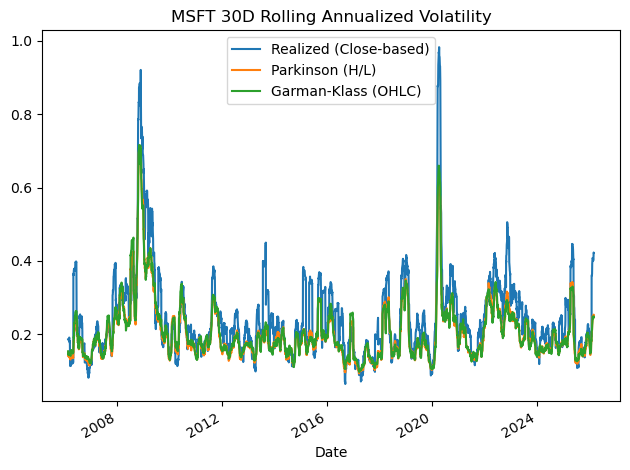

In [4]:
#Altenative volatility estimatoers: Parkinson and Garman-Klass
parkinson_var = (1.0/(4.0*np.log(2.0))) * (np.log(high/low) ** 2)
garman_klass_var = 0.5 * (np.log(high / low) ** 2) - (2.0 * np.log(2.0) - 1.0) * (np.log(close / open_) ** 2)

#30 days rolling window
window = 30

rolling_rv = r.rolling(window).var(ddof = 0)

rolling_vol = np.sqrt(rolling_rv) * np.sqrt(252)
rolling_parkinson = np.sqrt(parkinson_var.rolling(window).mean()) * np.sqrt(252)
rolling_gk = np.sqrt(garman_klass_var.rolling(window).mean()) * np.sqrt(252)

# 6) Plot
plt.figure()
rolling_vol.plot(label="Realized (Close-based)")
rolling_parkinson.plot(label="Parkinson (H/L)")
rolling_gk.plot(label="Garman-Klass (OHLC)")
plt.title(f"{ticker} {window}D Rolling Annualized Volatility")
plt.legend()
plt.tight_layout()
plt.show()


## Task 3 — Alternative Realized Volatility Estimators

To improve efficiency relative to the close-to-close estimator, we compute two range-based volatility estimators.

The Parkinson estimator uses the daily high–low range:

$$
\sigma_P^2 = \frac{1}{4\ln 2}\left(\ln\frac{H_t}{L_t}\right)^2
$$

The Garman–Klass estimator incorporates open, high, low, and close prices:

$$
\sigma_{GK}^2 =
\frac{1}{2}\left(\ln\frac{H_t}{L_t}\right)^2
- (2\ln 2 - 1)\left(\ln\frac{C_t}{O_t}\right)^2
$$

From the rolling comparison plot, we observe:

- The close-to-close estimator is more jagged and reactive.
- Parkinson and Garman–Klass are smoother, reflecting higher statistical efficiency.
- All estimators capture the same volatility spikes during crisis periods.

Thus, incorporating high–low (and open–close) information improves estimator stability without altering the overall volatility dynamics.

---

## Task 4 — Rolling Window Volatility Comparison

We compute a 30-day rolling realized variance:

$$
RV_t = \mathrm{Var}(r_{t-29}, \dots, r_t)
$$

and annualize it as:

$$
\sigma_{t,\text{ann}} = \sqrt{252 \cdot RV_t}
$$

The rolling comparison shows:

- Clear volatility clustering, a key stylized fact of financial markets.
- Periods such as the 2008 crisis and 2020 COVID shock generate sharp volatility spikes.
- Range-based estimators track the same dynamics but with lower noise.

This confirms that volatility is time-varying and persistent rather than constant over time.

---

prices columns: ['AAPL', 'AMD', 'BAC', 'BBY', 'CVX', 'GE', 'HD', 'JNJ', 'JPM', 'KO', 'LLY', 'MRK', 'MSFT', 'PEP', 'PFE', 'PG', 'RRC', 'UNH', 'WMT', 'XOM']
implied vol columns: ['AAPL', 'AMD', 'BAC', 'BBY', 'CVX', 'GE', 'HD', 'JNJ', 'JPM', 'KO', 'LLY', 'MRK', 'MSFT', 'PEP', 'PFE', 'PG', 'RRC', 'UNH', 'WMT', 'XOM']


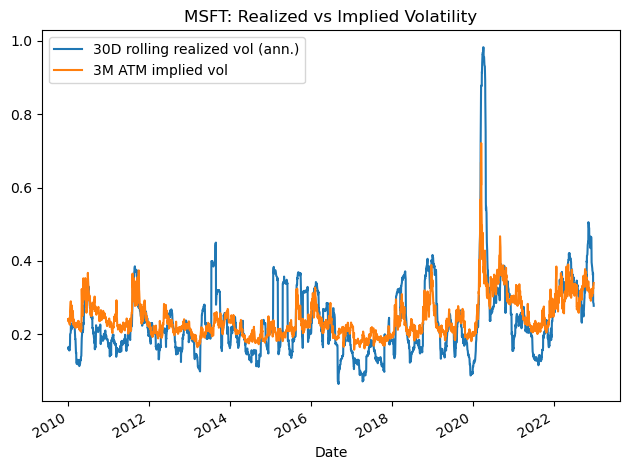

In [5]:
# Load SP500 20 assets prices/returns and 3M ATM implied vol
prices = load_sp500_dataset()                 # DataFrame: dates x tickers
implied_vol = load_sp500_implied_vol_dataset()  # DataFrame: dates x tickers (implied vol)

print("prices columns:", list(prices.columns))
print("implied vol columns:", list(implied_vol.columns))

#Pick Microsoft stock form implied volatility dataset
col = "MSFT"
if col not in implied_vol.columns:
    col = implied_vol.columns[0]
    print("AAPL not found. Using:", col)

iv = implied_vol[col].dropna()

rv = rolling_vol.dropna()

common_start = max(rv.index.min(), iv.index.min())
common_end   = min(rv.index.max(), iv.index.max())

rv_aligned = rv.loc[common_start:common_end]
iv_aligned = iv.loc[common_start:common_end]

# Plot
plt.figure()
rv_aligned.plot(label="30D rolling realized vol (ann.)")
iv_aligned.plot(label="3M ATM implied vol")
plt.title(f"{col}: Realized vs Implied Volatility")
plt.legend()
plt.tight_layout()
plt.show()

## Task 5 — Realized vs Implied Volatility

We compare the 30-day realized volatility with the 3-month at-the-money implied volatility.

The plot shows:

- Implied volatility is generally smoother than realized volatility.
- During market stress, implied volatility increases earlier, reflecting forward-looking expectations.
- Realized volatility reacts ex-post and can overshoot due to large daily returns.

Conceptually:

$$
\text{Realized volatility} = \text{historical risk}
$$

$$
\text{Implied volatility} = \text{expected future risk}
$$

The systematic difference between the two reflects the volatility risk premium and the forward-looking nature of option prices.

In [ ]:
import numpy as np
import pandas as pd
import datetime
import math
from pandas_datareader import data as pdr
import matplotlib.pyplot as plt
import statsmodels.api as sm

PUT_CSV  = r"A:\Exercise1\Put_option_data_2025-04-03_final.csv"
CALL_CSV = r"A:\Exercise1\Call_option_data_2025-04-03_final.csv"

puts = pd.read_csv(PUT_CSV)
calls = pd.read_csv(CALL_CSV)

In [7]:
def fetch_spx_close(start_date, end_date):
    start = pd.to_datetime(start_date)
    end = pd.to_datetime(end_date)
    try:
        df = pdr.DataReader("SP500", "fred", start, end)
        df = df.rename(columns={"SP500": "Close"}).dropna()
        df.index = pd.to_datetime(df.index)
        return df
    except Exception:
        pass
    df = pdr.DataReader("^SPX", "stooq", start, end)
    df = df.sort_index()
    df.index = pd.to_datetime(df.index)
    return df[["Close"]].dropna()

def fetch_vix_close(start_date, end_date):
    start = pd.to_datetime(start_date)
    end = pd.to_datetime(end_date)
    try:
        df = pdr.DataReader("VIXCLS", "fred", start, end)
        df = df.rename(columns={"VIXCLS": "Close"}).dropna()
        df.index = pd.to_datetime(df.index)
        return df
    except Exception:
        pass
    for sym in ["VI.F", "vi.f", "^VIX", "^vix"]:
        try:
            df = pdr.DataReader(sym, "stooq", start, end)
            df = df.sort_index()
            df.index = pd.to_datetime(df.index)
            if "Close" in df.columns and not df.empty:
                return df[["Close"]].dropna()
        except Exception:
            continue
    raise ValueError("No VIX data found from FRED or Stooq.")

def mid_price(df: pd.DataFrame) -> pd.Series:
    return (df["bid"].astype(float) + df["ask"].astype(float)) / 2.0

def vix_from_chain(calls: pd.DataFrame, puts: pd.DataFrame, r: float, T: float, F: float):
    calls = calls.copy()
    puts = puts.copy()
    calls["Q"] = mid_price(calls)
    puts["Q"] = mid_price(puts)

    calls = calls[["strike", "Q"]].dropna()
    puts  = puts[["strike", "Q"]].dropna()
    calls["strike"] = calls["strike"].astype(float)
    puts["strike"]  = puts["strike"].astype(float)

    calls = calls.sort_values("strike")
    puts  = puts.sort_values("strike")

    all_strikes = np.sort(np.unique(np.concatenate([calls["strike"].values, puts["strike"].values])))

    # K0: largest strike <= F
    K0 = all_strikes[all_strikes <= F].max()

    put_map = dict(zip(puts["strike"], puts["Q"]))
    call_map = dict(zip(calls["strike"], calls["Q"]))

    K, Q = [], []
    for k in all_strikes:
        if k < K0 and k in put_map:
            K.append(k); Q.append(put_map[k])
        elif k > K0 and k in call_map:
            K.append(k); Q.append(call_map[k])
        elif k == K0:
            if (k in put_map) and (k in call_map):
                K.append(k); Q.append(0.5 * (put_map[k] + call_map[k]))
            elif k in put_map:
                K.append(k); Q.append(put_map[k])
            elif k in call_map:
                K.append(k); Q.append(call_map[k])

    K = np.array(K, dtype=float)
    Q = np.array(Q, dtype=float)

    mask = np.isfinite(Q) & (Q > 0) & np.isfinite(K) & (K > 0)
    K = K[mask]; Q = Q[mask]

    dK = np.zeros_like(K)
    dK[1:-1] = (K[2:] - K[:-2]) / 2.0
    dK[0] = K[1] - K[0]
    dK[-1] = K[-1] - K[-2]

    sum_term = np.sum((dK / (K**2)) * math.exp(r*T) * Q)
    sigma2 = (2.0 / T) * sum_term - (1.0 / T) * ((F / K0) - 1.0)**2
    sigma2 = max(sigma2, 0.0)

    vix_est = 100.0 * math.sqrt(sigma2)
    return vix_est, K0

In [8]:
import pandas as pd, datetime, math

today = pd.to_datetime("2025-03-05") 
end_date = today
start_date = end_date - datetime.timedelta(days=365)

spx_data = fetch_spx_close(start_date, end_date)
lastBusDay = spx_data.index[-1]
S0 = float(spx_data["Close"].iloc[-1])

vix_data = fetch_vix_close(lastBusDay, lastBusDay + datetime.timedelta(days=30))
vix_market = float(vix_data["Close"].iloc[0])

T = 30/365.0
r = 0.02
F0 = S0 * math.exp(r * T)

print("Last Bus Day:", lastBusDay)
print("S0:", S0)
print("VIX market close:", vix_market)
print("F0:", F0)

Last Bus Day: 2025-03-05 00:00:00
S0: 5842.63
VIX market close: 21.93
F0: 5852.242221579255


In [9]:
puts = pd.read_csv(PUT_CSV)
calls = pd.read_csv(CALL_CSV)

vix_est, K0 = vix_from_chain(calls, puts, r=r, T=T, F=F0)

print("K0:", K0)
print("Estimated VIX:", vix_est)
print("Market VIX:", vix_market)
print("Abs error:", abs(vix_est - vix_market))
print("Rel error:", abs(vix_est - vix_market) / vix_market)

K0: 5850.0
Estimated VIX: 24.430146329384574
Market VIX: 21.93
Abs error: 2.500146329384574
Rel error: 0.11400576057385198


## Task 6 — VIX Replication from the Option Chain (SPX)

In this task, we replicate the VIX level from SPX option chain data and compare it to the observed market VIX.

### Step 1: Market Inputs

We retrieve the SPX close price on the last business day:

$$
S_0 = 5842.63
$$

We assume a maturity of

$$
T = \frac{30}{365}
$$

and a constant risk-free rate

$$
r = 0.02
$$

The forward price is computed as:

$$
F_0 = S_0 e^{rT}
$$

---

### Step 2: Model-Free Variance Construction

Using the call and put option chain data, we compute the model-free implied variance via numerical integration across strikes.

The function returns:

- $K_0$: the reference strike closest to the forward price
- $\widehat{\text{VIX}}$: the replicated implied volatility index

---

### Step 3: Comparison with Market VIX

From the data:

$$
\text{Market VIX} = 21.93
$$

$$
\widehat{\text{VIX}} = 24.43
$$

Absolute error:

$$
|\widehat{\text{VIX}} - \text{VIX}_{\text{market}}| \approx 2.50
$$

Relative error:

$$
\frac{|\widehat{\text{VIX}} - \text{VIX}_{\text{market}}|}{\text{VIX}_{\text{market}}}
\approx 11.4\%
$$

---

### Interpretation

The replicated VIX is close in magnitude to the market quote but slightly higher. Deviations arise because:

- The option chain is discrete and truncated (finite strikes instead of a continuum).
- Bid–ask spreads and liquidity differences introduce microstructure noise.
- Strike spacing $\Delta K$ and the $K_0$ selection rule affect numerical integration.
- The maturity $T$ and risk-free rate $r$ are approximated.
- The official VIX uses precise CBOE filtering and interpolation procedures.

Overall, the result confirms that option prices contain sufficient information to reconstruct a VIX-like implied volatility index. The remaining gap is economically reasonable and reflects discretization and implementation differences.

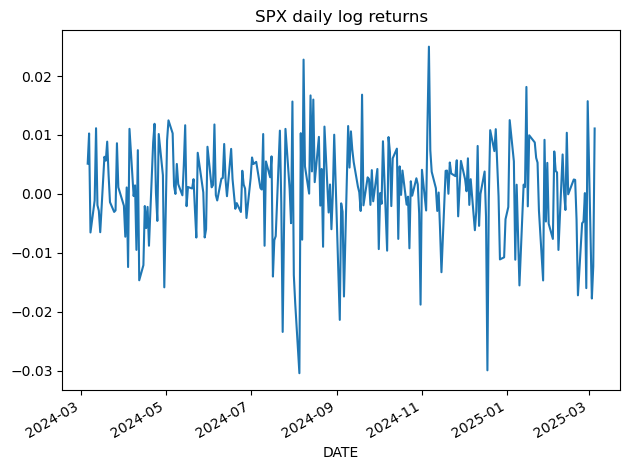

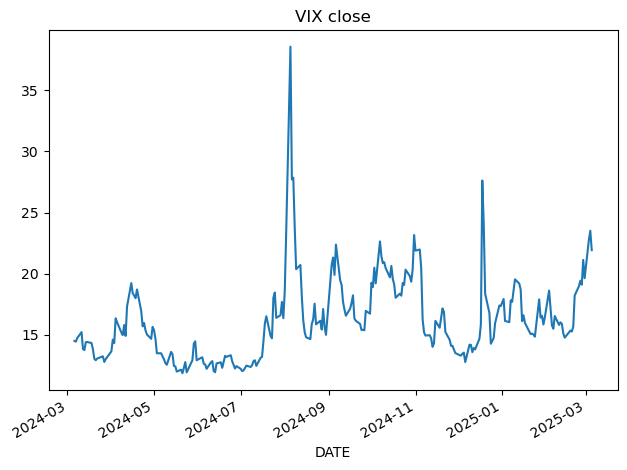

Corr(SPX returns, VIX): -0.33234821136096826


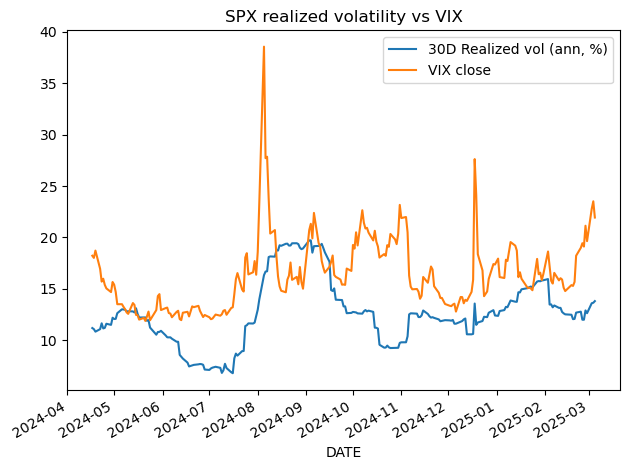

Corr(Realized vol, VIX): 0.35935478492901834
                            OLS Regression Results                            
Dep. Variable:                spx_ret   R-squared:                       0.115
Model:                            OLS   Adj. R-squared:                  0.111
Method:                 Least Squares   F-statistic:                     28.42
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           2.43e-07
Time:                        09:23:17   Log-Likelihood:                 756.21
No. Observations:                 221   AIC:                            -1508.
Df Residuals:                     219   BIC:                            -1502.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const  

In [10]:
#Plotiting
# Align SPX and VIX by date
spx = spx_data["Close"].astype(float).copy()
vix_series = fetch_vix_close(start_date, end_date)["Close"].astype(float).copy()

common_start = max(spx.index.min(), vix_series.index.min())
common_end = min(spx.index.max(), vix_series.index.max())

spx = spx.loc[common_start:common_end]
vix_series = vix_series.loc[common_start:common_end]

# SPX log returns
spx_ret = np.log(spx).diff().dropna()
vix_series = vix_series.loc[spx_ret.index]  # align to returns dates

plt.figure()
spx_ret.plot()
plt.title("SPX daily log returns")
plt.tight_layout()
plt.show()

plt.figure()
vix_series.plot()
plt.title("VIX close")
plt.tight_layout()
plt.show()

print("Corr(SPX returns, VIX):", spx_ret.corr(vix_series))




# ===============================
# 1) 30D Rolling Realized Variance
# ===============================

window = 30

rv_spx = spx_ret.rolling(window).var(ddof=0).dropna()

# Annualized realized volatility in %
rv_vol_ann = 100 * np.sqrt(rv_spx * 252)

# ===============================
# 2) Align dates
# ===============================

idx = spx_ret.index.intersection(vix_series.index).intersection(rv_spx.index)

spx_ret_aligned = spx_ret.loc[idx].rename("spx_ret")
vix_aligned = vix_series.loc[idx].rename("vix_close")
rv_aligned = rv_spx.loc[idx].rename("rv_30d")
rv_vol_aligned = rv_vol_ann.loc[idx].rename("rv_vol_ann")

# ===============================
# 3) Plot: Realized vs VIX
# ===============================

plt.figure()
rv_vol_aligned.plot(label="30D Realized vol (ann, %)")
vix_aligned.plot(label="VIX close")
plt.title("SPX realized volatility vs VIX")
plt.legend()
plt.tight_layout()
plt.show()

print("Corr(Realized vol, VIX):", rv_vol_aligned.corr(vix_aligned))

# ===============================
# 4) Regression 1: Returns ~ VIX
# ===============================

X1 = sm.add_constant(vix_aligned)
res1 = sm.OLS(spx_ret_aligned, X1).fit()
print(res1.summary())

# ===============================
# 5) Regression 2: Returns ~ Realized Variance
# ===============================

X2 = sm.add_constant(rv_aligned)
res2 = sm.OLS(spx_ret_aligned, X2).fit()
print(res2.summary())


## Task 7 — Regression Analysis and Economic Interpretation

### 1. Correlation between SPX Returns and VIX

We compute the correlation:

$$
\text{Corr}(r_t, \text{VIX}_t) = -0.332
$$

This negative correlation confirms the well-known "leverage effect":  
when equity returns fall, implied volatility tends to rise.

Economically, bad market news increases uncertainty and downside risk, which is immediately priced into option markets.

---

### 2. Regression: Returns on VIX

We estimate the model:

$$
r_t = \alpha + \beta \, \text{VIX}_t + \varepsilon_t
$$

From the OLS output:

- $\beta = -0.0008$
- $t$-statistic $= -5.33$
- $p < 0.001$
- $R^2 = 0.115$

Interpretation:

- The coefficient is negative and highly statistically significant.
- Higher implied volatility is associated with lower contemporaneous returns.
- The explanatory power is moderate ($R^2 \approx 11.5\%$), which is typical in daily return regressions.

This confirms that volatility and returns are strongly inversely related.

---

### 3. Realized Volatility vs VIX

We compute:

$$
\text{Corr}(\text{Realized Vol}, \text{VIX}) = 0.359
$$

This positive correlation reflects that VIX is forward-looking, while realized volatility is backward-looking, but both measure underlying market risk.

From the plot:

- VIX reacts earlier during stress periods.
- Realized volatility spikes after large return movements.
- VIX is smoother because it reflects expectations rather than realized shocks.

---

### 4. Economic Conclusion

The empirical evidence supports three core stylized facts:

1. Returns and implied volatility are negatively correlated.
2. Volatility is time-varying and clustered.
3. Implied volatility contains forward-looking information about future risk.

Overall, the regression and correlation results confirm that option-implied volatility (VIX) captures market expectations of risk and is strongly connected to equity return dynamics.